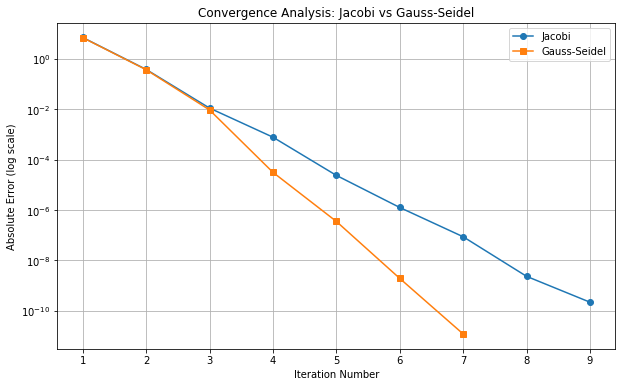

Tolerance 0.001: Jacobi = 4 iterations, GS = 4 iterations
Tolerance 1e-06: Jacobi = 7 iterations, GS = 5 iterations
Tolerance 1e-09: Jacobi = 9 iterations, GS = 7 iterations


In [4]:
import numpy as np
import time
import matplotlib.pyplot as plt

A = np.array([[3, -0.1, -0.2],
              [0.1, 7, -0.3],
              [0.3, -0.2, 10]], dtype=float)
b = np.array([7.85, -19.3, 71.4], dtype=float)
x0 = np.zeros(3) # Initial guess
tols = [1e-3, 1e-6, 1e-9]

def solve_system(method, A, b, x0, tol):
    n = len(b)
    x = x0.copy()
    errors = []
    for k in range(100):
        x_prev = x.copy()
        if method == 'jacobi':
            x_new = np.zeros_like(x)
            for i in range(n):
                s = sum(A[i][j] * x[j] for j in range(n) if j != i)
                x_new[i] = (b[i] - s) / A[i][i]
            x = x_new
        else: # Gauss-Seidel
            for i in range(n):
                s1 = sum(A[i][j] * x[j] for j in range(i))
                s2 = sum(A[i][j] * x_prev[j] for j in range(i + 1, n))
                x[i] = (b[i] - s1 - s2) / A[i][i]
        
        # Absolute error between iterations
        err = np.linalg.norm(x - x_prev, ord=np.inf)
        errors.append(err)
        if err < tol:
            return x, k + 1, errors
    return x, 100, errors

# Convergence Plotting
plt.figure(figsize=(10, 6))

_, it_j, err_j = solve_system('jacobi', A, b, x0, 1e-9)
_, it_gs, err_gs = solve_system('gauss_seidel', A, b, x0, 1e-9)

plt.semilogy(range(1, it_j + 1), err_j, 'o-', label='Jacobi')
plt.semilogy(range(1, it_gs + 1), err_gs, 's-', label='Gauss-Seidel')
plt.xlabel('Iteration Number')
plt.ylabel('Absolute Error (log scale)')
plt.title('Convergence Analysis: Jacobi vs Gauss-Seidel')
plt.legend()
plt.grid(True, which="both", ls="-")
plt.show()

# Iteration Comparison
for t in tols:
    _, ij, _ = solve_system('jacobi', A, b, x0, t)
    _, ig, _ = solve_system('gauss_seidel', A, b, x0, t)
    print(f"Tolerance {t}: Jacobi = {ij} iterations, GS = {ig} iterations")

As the tolerance becomes stricter, the number of iterations increases because the method must work harder to reach a more precise answer. Because these methods have linear convergence, each additional digit of precision required adds a consistent number of extra steps. This relationship is clearly seen in the results, where moving from 10^-3 to 10^-9 clearly increases the iteration count for both Jacobi and Gauss-Seidel. Ultimately, tighter tolerances make the efficiency of Gauss-Seidel even more obvious, as it consistently reaches the goal in less iterations than the Jacobi method.